# Машинное обучение, ФКН ВШЭ

## Практическое задание 5. Решающие деревья

### Общая информация
Дата выдачи: 29.11.2024

Мягий дедлайн: 23:59 11.12.2024

Жестокий дедлайн: 23:59 13.12.2024

### О задании

Задание состоит из трёх разделов:
1. В первом разделе вы научитесь применять деревья из sklearn для задачи классификации. Вы посмотрите какие разделяющие поверхности деревья строят для различных датасетов и проанализируете их зависимость от различных гиперпараметров.
2. Во втором разделе вы попробуете реализовать свое решающее дерево для классификации и сравните его со стандартное имплементацией из sklearn.
3. В третьем разделе вы сделаете решающее дерево для регрессии, в листьях которого линейные модели.

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 12.5 баллов.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.


### Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-05-trees-Username.ipynb
* Модуль hw5code.py
* Ссылки на посылки в Яндекс.Контесте для обеих задач

В контест [https://contest.yandex.ru/contest/72492] нужно отправить файл hw5code.py с реализованными функциями и классами.

Username — ваша фамилия и имя на латинице именно в таком порядке

Для удобства проверки самостоятельно посчитайте свою максимальную оценку (исходя из набора решенных задач) и укажите ниже:

__Оценка:__

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import Colormap, ListedColormap
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

# 1. Решающие деревья. Визуализация.

В этой части мы рассмотрим три простых двумерных датасета сделанных с помощью `make_moons`, `make_circles`, `make_classification` и посмотрим как ведет себя разделяющая поверхность в зависимости от различных гиперпараметров.

In [2]:
from sklearn.datasets import make_moons, make_circles, make_classification
datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2, class_sep=.8, random_state=3,
                        n_redundant=0, )
]

In [3]:
palette = sns.color_palette(n_colors=3)
cmap = ListedColormap(palette)

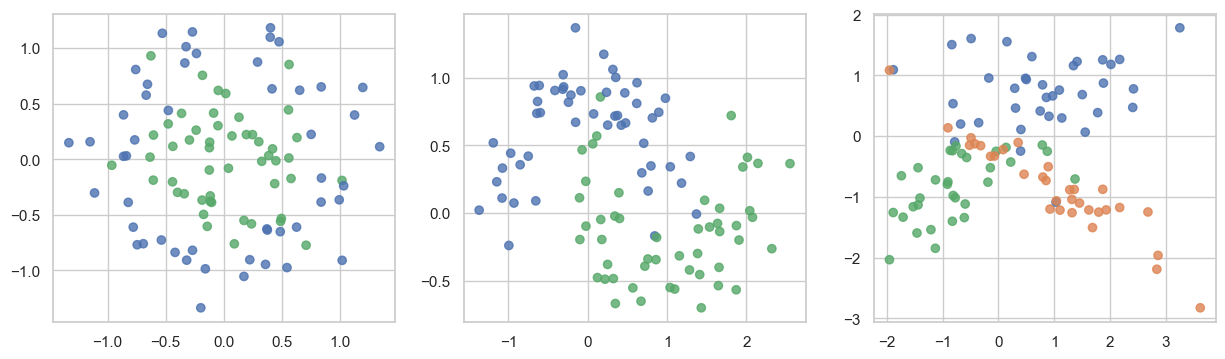

In [4]:
plt.figure(figsize=(15, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap, alpha=.8)

__Задание 1. (1 балл)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности (для этого воспользуйтесь функцией `plot_surface`, пример ниже). Посчитайте accuracy на обучающей и тестовой выборках. Сильно ли деревья переобучились?

In [5]:
def plot_surface(clf, X, y):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=.7,
                edgecolors=np.array(palette)[y], linewidths=2)

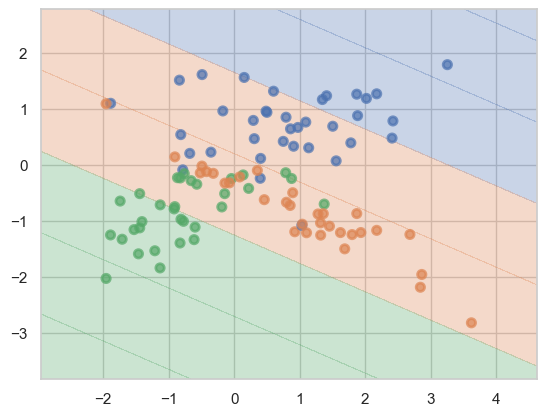

In [6]:
# Пример:
from sklearn.linear_model import LinearRegression
X, y = datasets[2]
lr  = LinearRegression().fit(X, y)
plot_surface(lr, X, y)

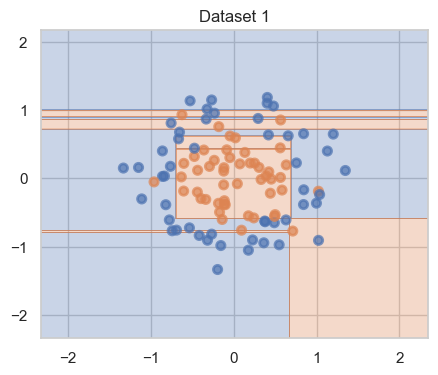

Dataset 1 - Train Accuracy: 1.00, Test Accuracy: 0.73


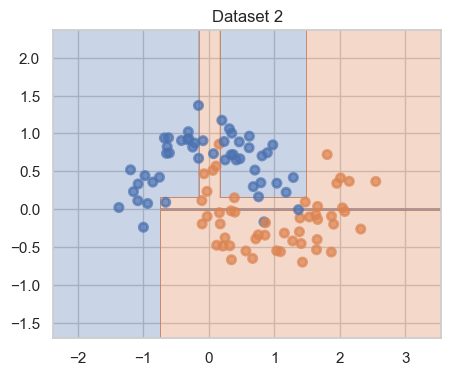

Dataset 2 - Train Accuracy: 1.00, Test Accuracy: 0.87


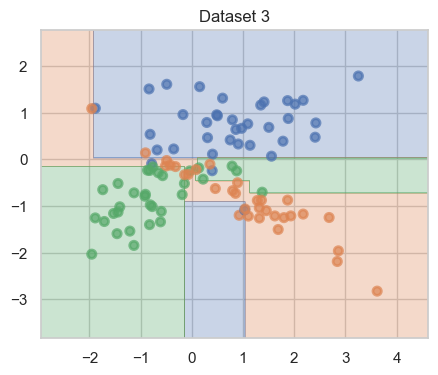

Dataset 3 - Train Accuracy: 1.00, Test Accuracy: 0.80


In [7]:
for i, (X, y) in enumerate(datasets):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    clf = DecisionTreeClassifier()
    clf.fit(X_train, y_train)
    
    plt.figure(figsize=(5, 4))
    plot_surface(clf, X, y)
    plt.title(f"Dataset {i+1}")
    plt.show()
    
    train_accuracy = clf.score(X_train, y_train)
    test_accuracy = clf.score(X_test, y_test)
    
    print(f"Dataset {i+1} - Train Accuracy: {train_accuracy:.2f}, Test Accuracy: {test_accuracy:.2f}")

__Ответ:__ Очень сильно. Аккураси буквально единица на тестовой выборке плюс видно по графикам что деревья подогнались под выборку

__Задание 2. (1.25 баллов)__

Попробуйте перебрать несколько параметров для регуляризации (напр. `max_depth`, `min_samples_leaf`). Для каждого набора гиперпараметров постройте разделяющую поверхность, выведите обучающую и тестовую ошибки / accuracy. Можно делать кросс-валидацию или просто разбиение на трейн и тест, главное делайте каждый раз одинаковое разбиение, чтобы можно было корректно сравнивать (помните же, что итоговое дерево сильно зависит от небольшого изменения обучающей выборки?). Проследите как меняется разделяющая поверхность и обобщающая способность. Почему так происходит, одинаково ли изменение для разных датасетов?

__Бонус (0.75 баллов)__

Вместо того, чтобы рисовать  кучу графиков, сделайте интерактивную визуализацию разделяющей гиперплоскости с помощью библиотеки `plotly` (конкретнее, вам пригодится `plotly.graph_objects`): у вас должен получиться виджет с ползунком, по которому можно выбрать параметры `max_depth` и `min_samples_leaf` и посмотреть, как в зависимости от них меняется разделяющая поверхность и прогнозы модели. Если всё сделать аккуратно, получится очень красиво. Помните, что при загрузке в anytask виджеты могут много весить и надо подождать. Если ваш ноутбук не загружается -- попробуйте загрузить сначала с очищенным выводом этой ячейки. 

Заранее предупреждаем, что бонус сложный. Полезно будет ознакомиться:
 - https://plotly.com/python/sliders/
 - https://plotly.com/python/dropdowns/
 - https://plotly.com/python/knn-classification/

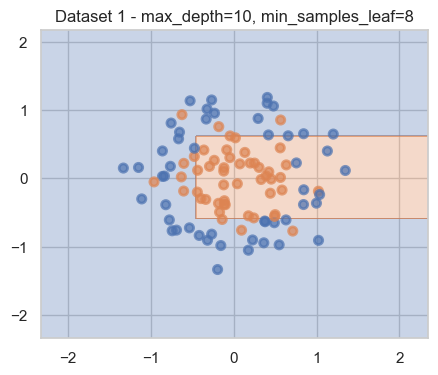

Dataset 1 - max_depth=10, min_samples_leaf=8 - Train Accuracy: 0.83, Test Accuracy: 0.80


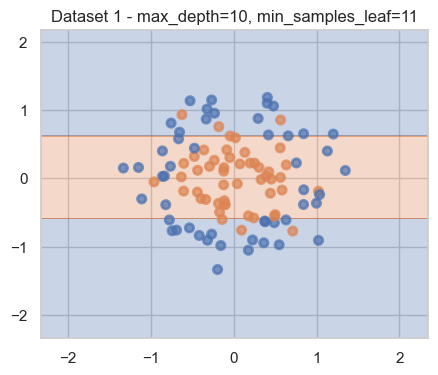

Dataset 1 - max_depth=10, min_samples_leaf=11 - Train Accuracy: 0.81, Test Accuracy: 0.67


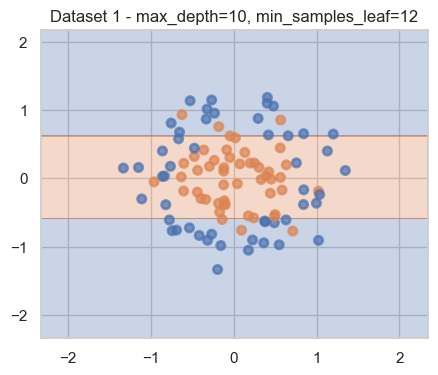

Dataset 1 - max_depth=10, min_samples_leaf=12 - Train Accuracy: 0.81, Test Accuracy: 0.67


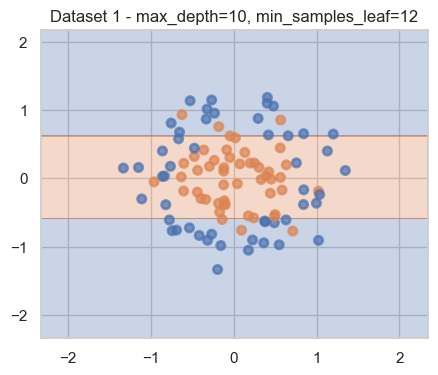

Dataset 1 - max_depth=10, min_samples_leaf=12 - Train Accuracy: 0.81, Test Accuracy: 0.67


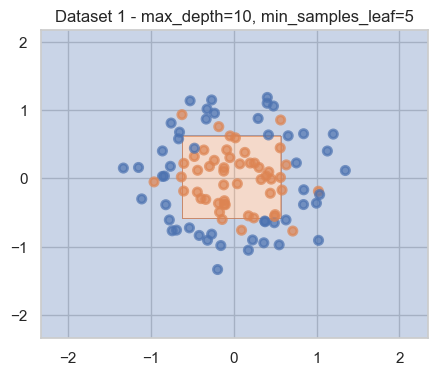

Dataset 1 - max_depth=10, min_samples_leaf=5 - Train Accuracy: 0.87, Test Accuracy: 0.90


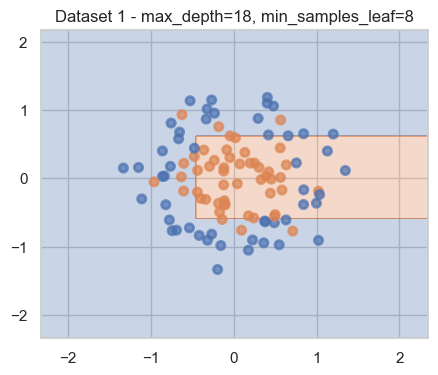

Dataset 1 - max_depth=18, min_samples_leaf=8 - Train Accuracy: 0.83, Test Accuracy: 0.80


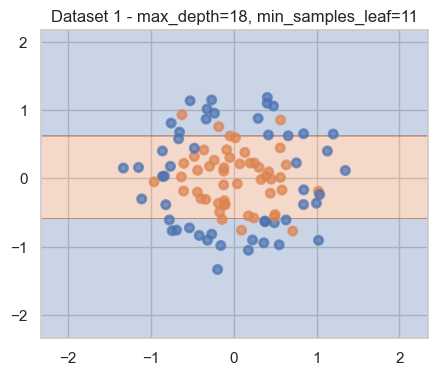

Dataset 1 - max_depth=18, min_samples_leaf=11 - Train Accuracy: 0.81, Test Accuracy: 0.67


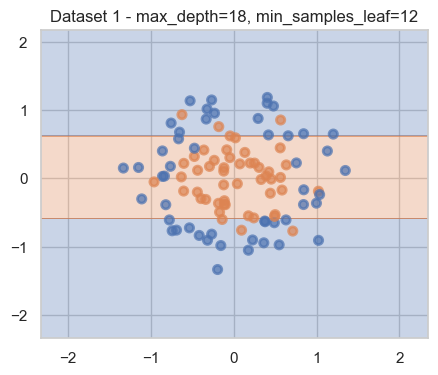

Dataset 1 - max_depth=18, min_samples_leaf=12 - Train Accuracy: 0.81, Test Accuracy: 0.67


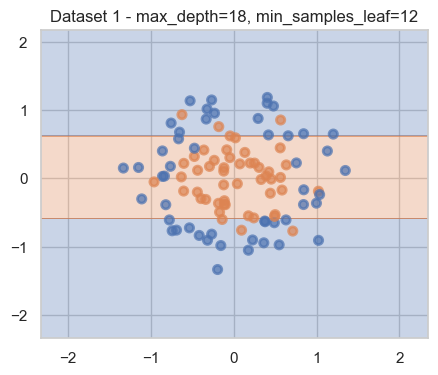

Dataset 1 - max_depth=18, min_samples_leaf=12 - Train Accuracy: 0.81, Test Accuracy: 0.67


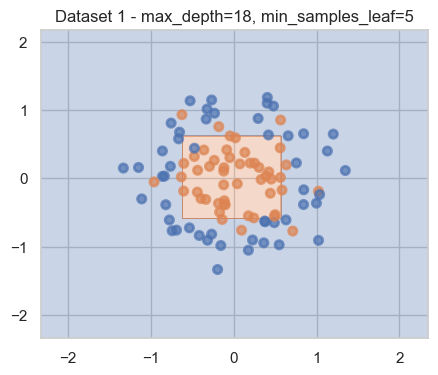

Dataset 1 - max_depth=18, min_samples_leaf=5 - Train Accuracy: 0.87, Test Accuracy: 0.90


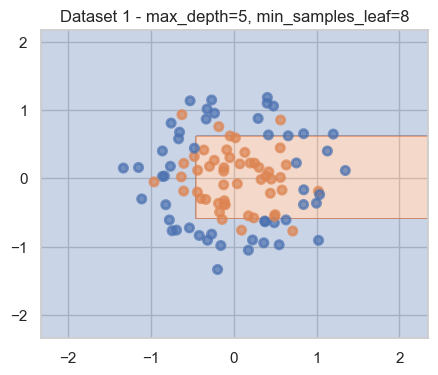

Dataset 1 - max_depth=5, min_samples_leaf=8 - Train Accuracy: 0.83, Test Accuracy: 0.80


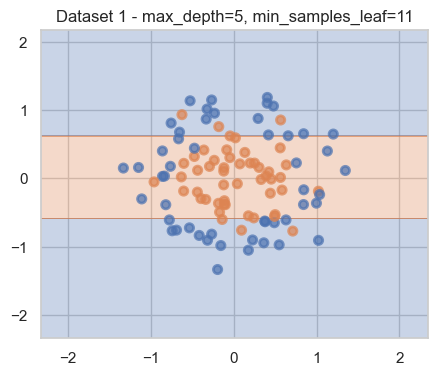

Dataset 1 - max_depth=5, min_samples_leaf=11 - Train Accuracy: 0.81, Test Accuracy: 0.67


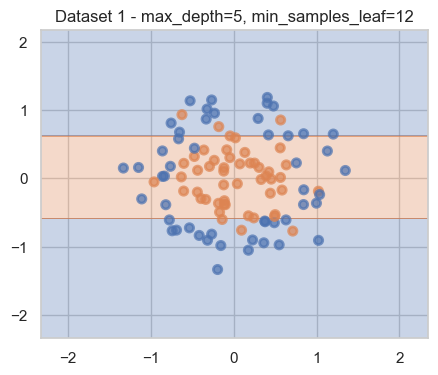

Dataset 1 - max_depth=5, min_samples_leaf=12 - Train Accuracy: 0.81, Test Accuracy: 0.67


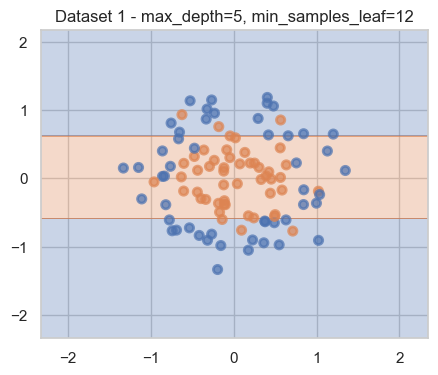

Dataset 1 - max_depth=5, min_samples_leaf=12 - Train Accuracy: 0.81, Test Accuracy: 0.67


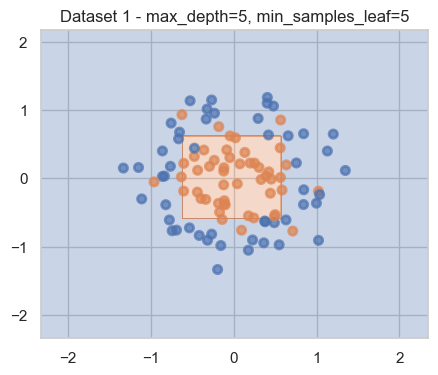

Dataset 1 - max_depth=5, min_samples_leaf=5 - Train Accuracy: 0.87, Test Accuracy: 0.90


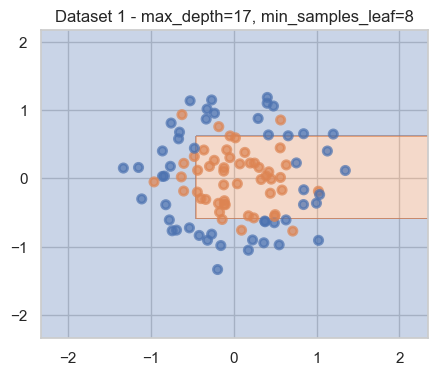

Dataset 1 - max_depth=17, min_samples_leaf=8 - Train Accuracy: 0.83, Test Accuracy: 0.80


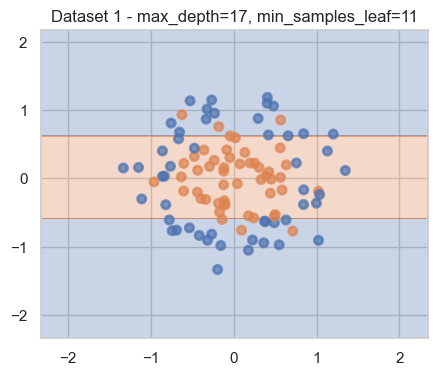

Dataset 1 - max_depth=17, min_samples_leaf=11 - Train Accuracy: 0.81, Test Accuracy: 0.67


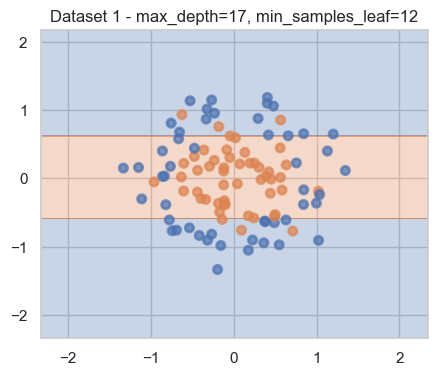

Dataset 1 - max_depth=17, min_samples_leaf=12 - Train Accuracy: 0.81, Test Accuracy: 0.67


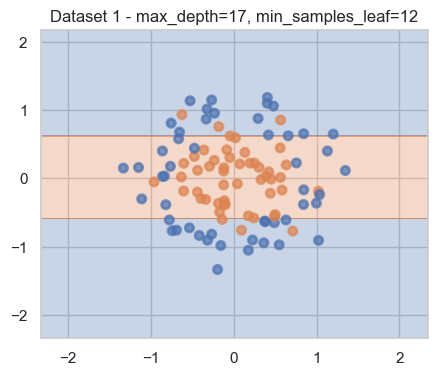

Dataset 1 - max_depth=17, min_samples_leaf=12 - Train Accuracy: 0.81, Test Accuracy: 0.67


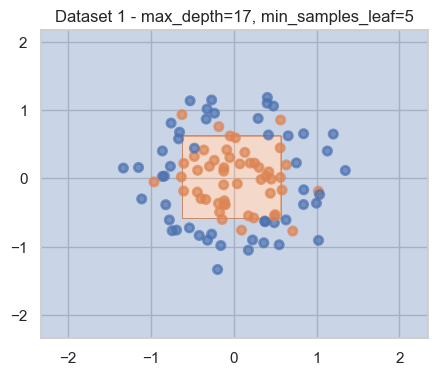

Dataset 1 - max_depth=17, min_samples_leaf=5 - Train Accuracy: 0.87, Test Accuracy: 0.90


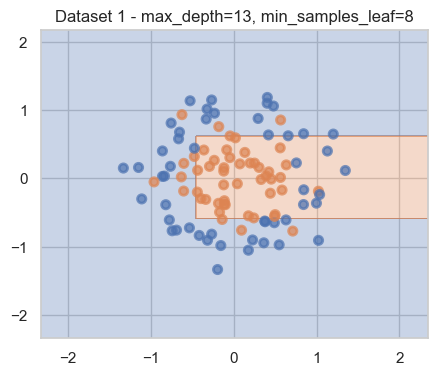

Dataset 1 - max_depth=13, min_samples_leaf=8 - Train Accuracy: 0.83, Test Accuracy: 0.80


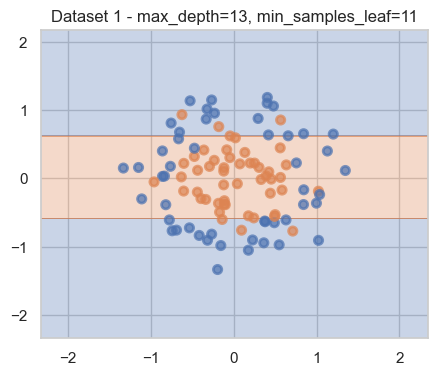

Dataset 1 - max_depth=13, min_samples_leaf=11 - Train Accuracy: 0.81, Test Accuracy: 0.67


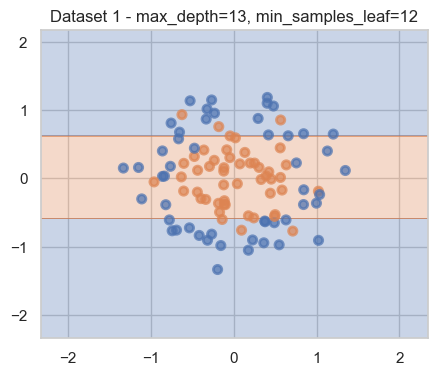

Dataset 1 - max_depth=13, min_samples_leaf=12 - Train Accuracy: 0.81, Test Accuracy: 0.67


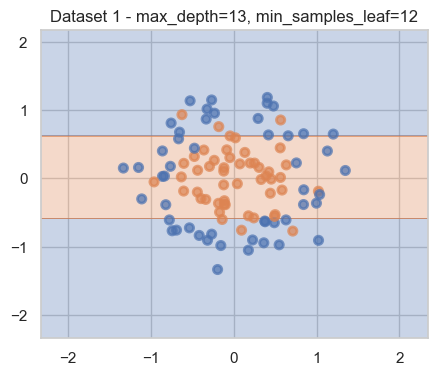

Dataset 1 - max_depth=13, min_samples_leaf=12 - Train Accuracy: 0.81, Test Accuracy: 0.67


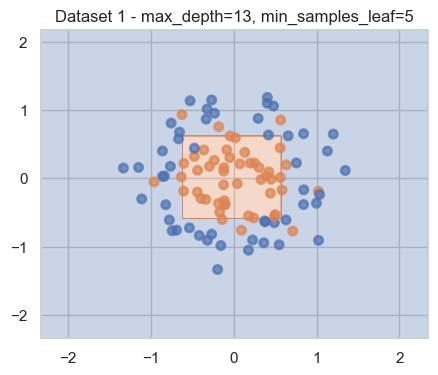

Dataset 1 - max_depth=13, min_samples_leaf=5 - Train Accuracy: 0.87, Test Accuracy: 0.90


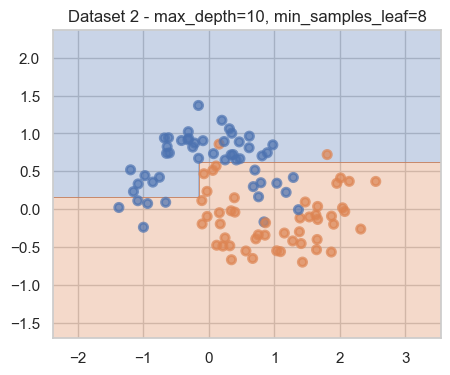

Dataset 2 - max_depth=10, min_samples_leaf=8 - Train Accuracy: 0.87, Test Accuracy: 0.77


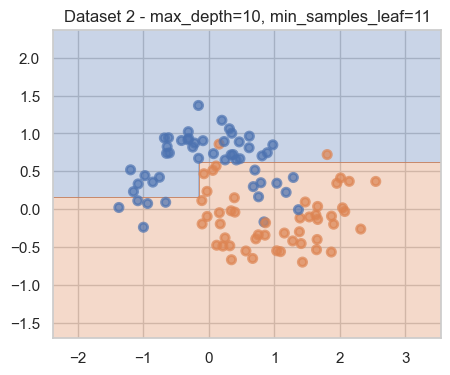

Dataset 2 - max_depth=10, min_samples_leaf=11 - Train Accuracy: 0.87, Test Accuracy: 0.77


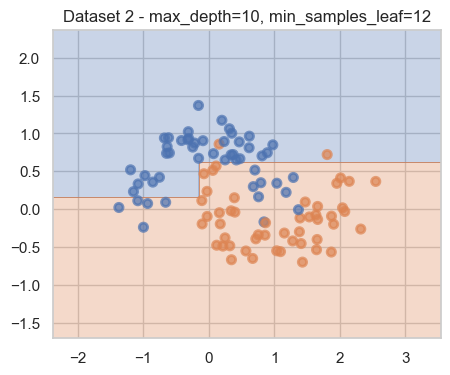

Dataset 2 - max_depth=10, min_samples_leaf=12 - Train Accuracy: 0.87, Test Accuracy: 0.77


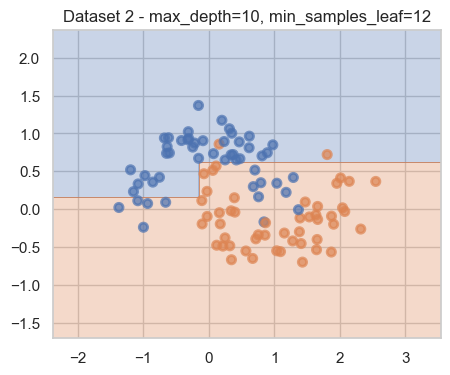

Dataset 2 - max_depth=10, min_samples_leaf=12 - Train Accuracy: 0.87, Test Accuracy: 0.77


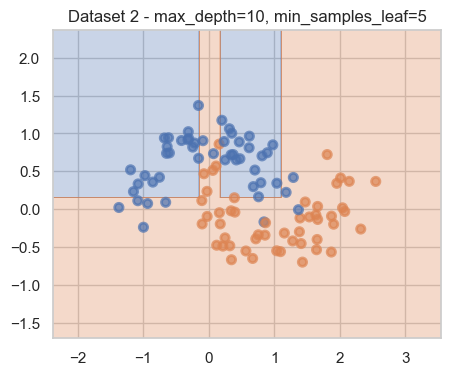

Dataset 2 - max_depth=10, min_samples_leaf=5 - Train Accuracy: 0.96, Test Accuracy: 0.73


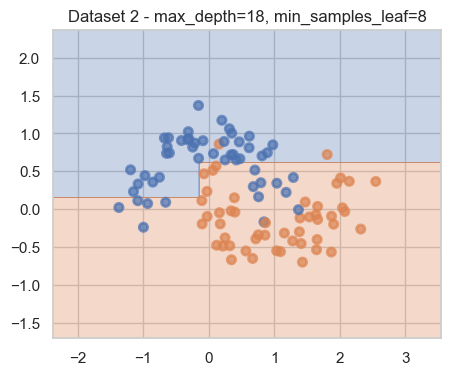

Dataset 2 - max_depth=18, min_samples_leaf=8 - Train Accuracy: 0.87, Test Accuracy: 0.77


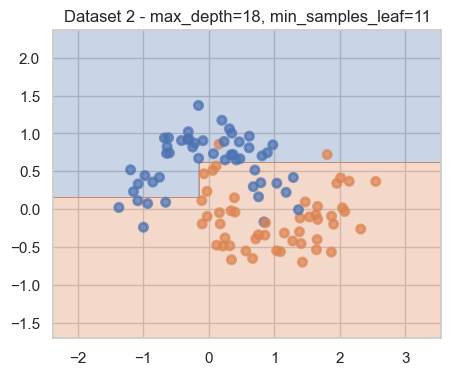

Dataset 2 - max_depth=18, min_samples_leaf=11 - Train Accuracy: 0.87, Test Accuracy: 0.77


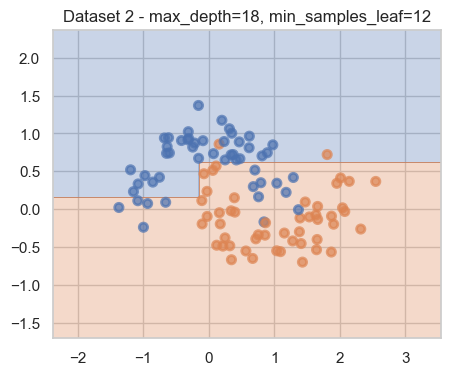

Dataset 2 - max_depth=18, min_samples_leaf=12 - Train Accuracy: 0.87, Test Accuracy: 0.77


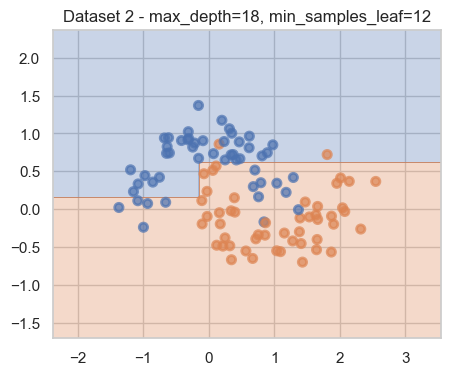

Dataset 2 - max_depth=18, min_samples_leaf=12 - Train Accuracy: 0.87, Test Accuracy: 0.77


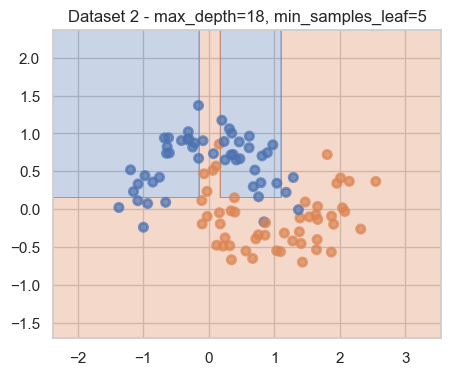

Dataset 2 - max_depth=18, min_samples_leaf=5 - Train Accuracy: 0.96, Test Accuracy: 0.73


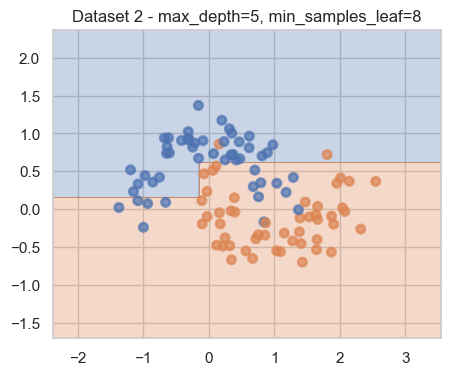

Dataset 2 - max_depth=5, min_samples_leaf=8 - Train Accuracy: 0.87, Test Accuracy: 0.77


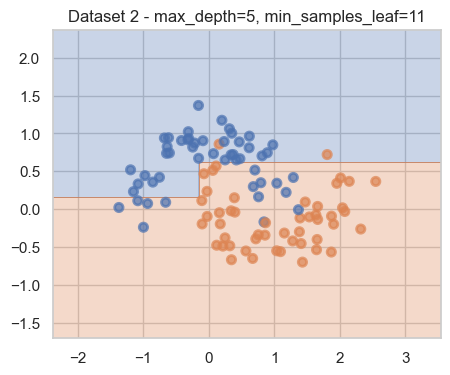

Dataset 2 - max_depth=5, min_samples_leaf=11 - Train Accuracy: 0.87, Test Accuracy: 0.77


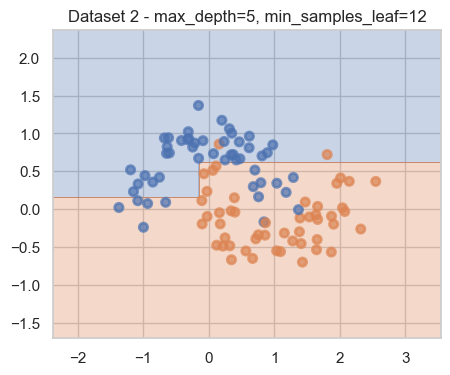

Dataset 2 - max_depth=5, min_samples_leaf=12 - Train Accuracy: 0.87, Test Accuracy: 0.77


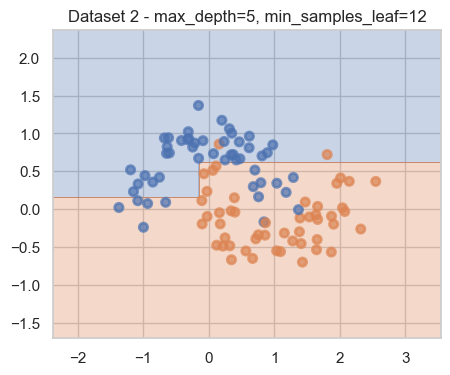

Dataset 2 - max_depth=5, min_samples_leaf=12 - Train Accuracy: 0.87, Test Accuracy: 0.77


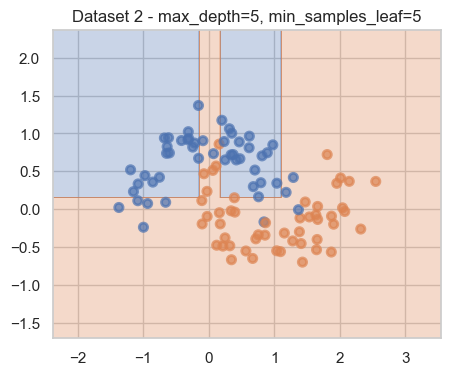

Dataset 2 - max_depth=5, min_samples_leaf=5 - Train Accuracy: 0.96, Test Accuracy: 0.73


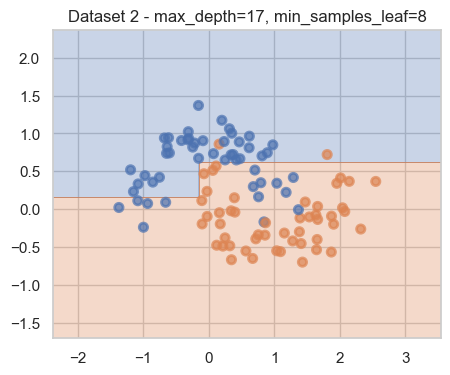

Dataset 2 - max_depth=17, min_samples_leaf=8 - Train Accuracy: 0.87, Test Accuracy: 0.77


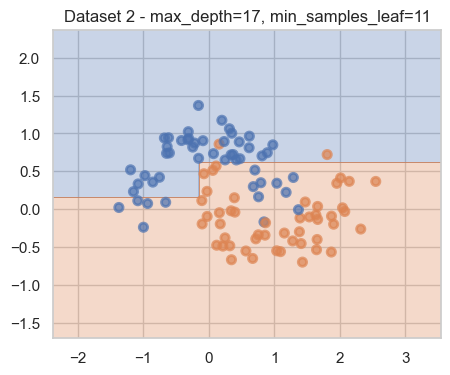

Dataset 2 - max_depth=17, min_samples_leaf=11 - Train Accuracy: 0.87, Test Accuracy: 0.77


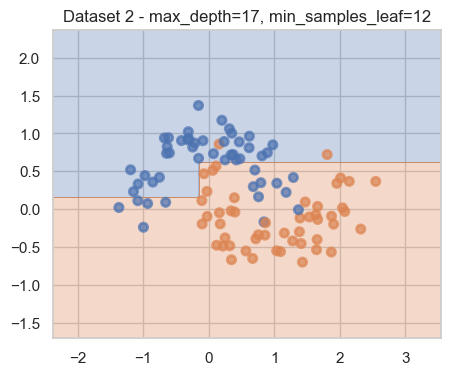

Dataset 2 - max_depth=17, min_samples_leaf=12 - Train Accuracy: 0.87, Test Accuracy: 0.77


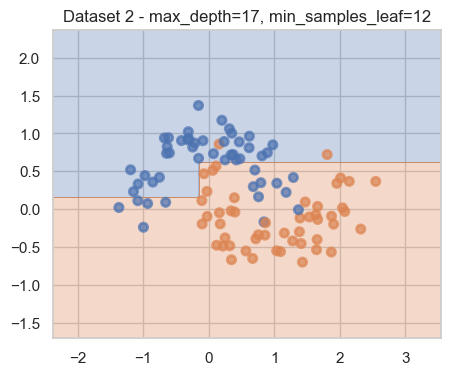

Dataset 2 - max_depth=17, min_samples_leaf=12 - Train Accuracy: 0.87, Test Accuracy: 0.77


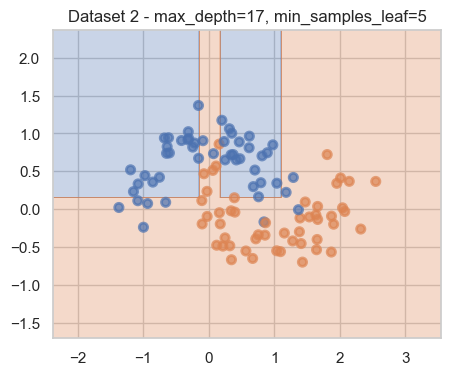

Dataset 2 - max_depth=17, min_samples_leaf=5 - Train Accuracy: 0.96, Test Accuracy: 0.73


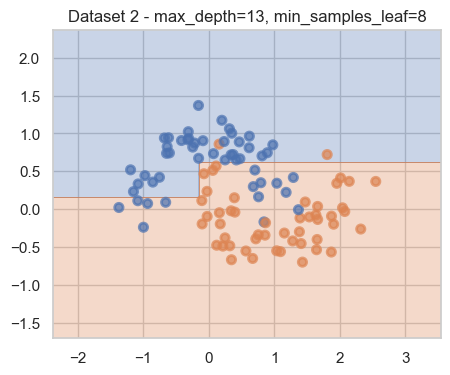

Dataset 2 - max_depth=13, min_samples_leaf=8 - Train Accuracy: 0.87, Test Accuracy: 0.77


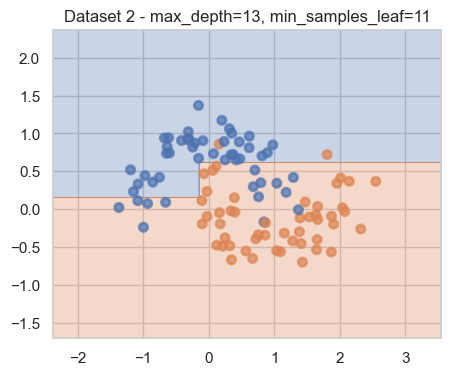

Dataset 2 - max_depth=13, min_samples_leaf=11 - Train Accuracy: 0.87, Test Accuracy: 0.77


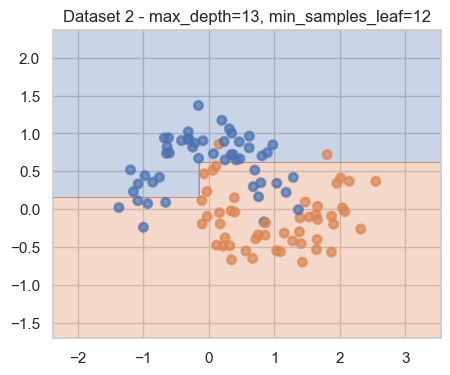

Dataset 2 - max_depth=13, min_samples_leaf=12 - Train Accuracy: 0.87, Test Accuracy: 0.77


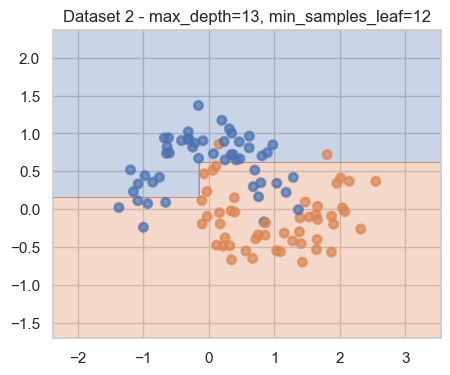

Dataset 2 - max_depth=13, min_samples_leaf=12 - Train Accuracy: 0.87, Test Accuracy: 0.77


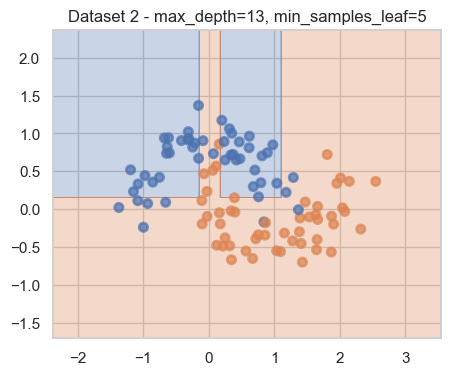

Dataset 2 - max_depth=13, min_samples_leaf=5 - Train Accuracy: 0.96, Test Accuracy: 0.73


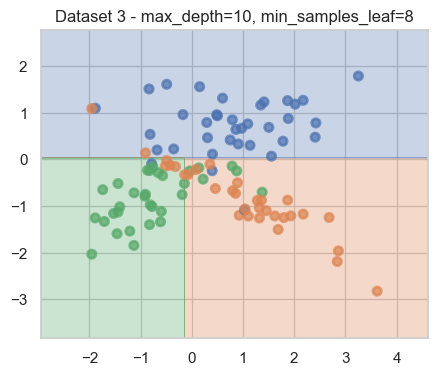

Dataset 3 - max_depth=10, min_samples_leaf=8 - Train Accuracy: 0.89, Test Accuracy: 0.77


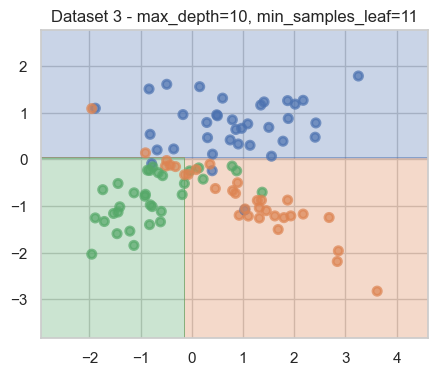

Dataset 3 - max_depth=10, min_samples_leaf=11 - Train Accuracy: 0.89, Test Accuracy: 0.77


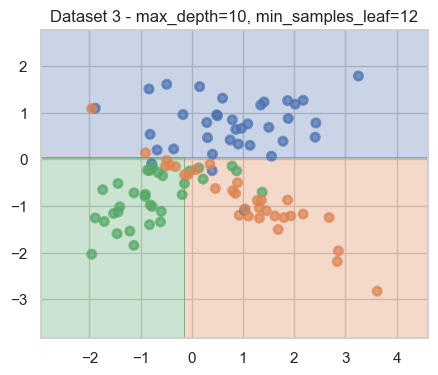

Dataset 3 - max_depth=10, min_samples_leaf=12 - Train Accuracy: 0.89, Test Accuracy: 0.77


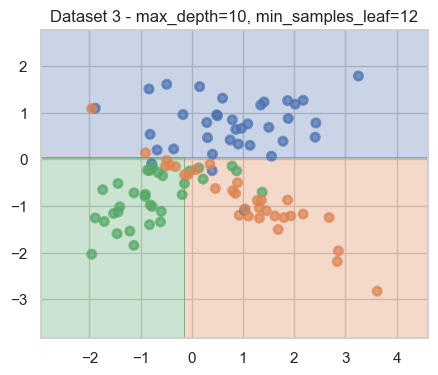

Dataset 3 - max_depth=10, min_samples_leaf=12 - Train Accuracy: 0.89, Test Accuracy: 0.77


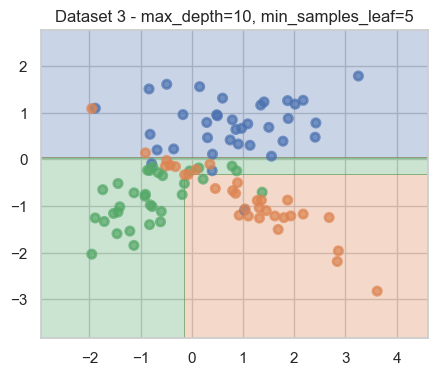

Dataset 3 - max_depth=10, min_samples_leaf=5 - Train Accuracy: 0.90, Test Accuracy: 0.77


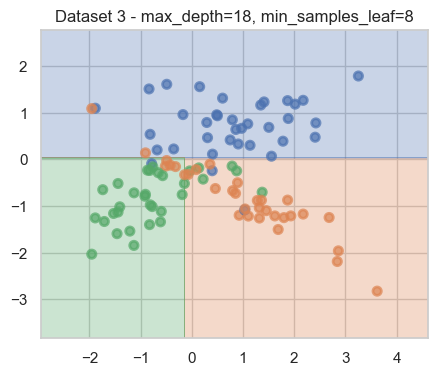

Dataset 3 - max_depth=18, min_samples_leaf=8 - Train Accuracy: 0.89, Test Accuracy: 0.77


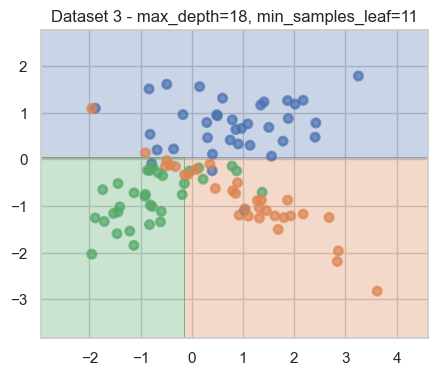

Dataset 3 - max_depth=18, min_samples_leaf=11 - Train Accuracy: 0.89, Test Accuracy: 0.77


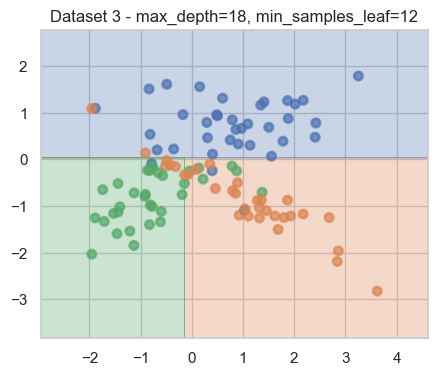

Dataset 3 - max_depth=18, min_samples_leaf=12 - Train Accuracy: 0.89, Test Accuracy: 0.77


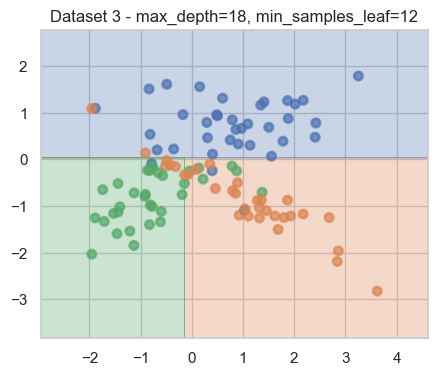

Dataset 3 - max_depth=18, min_samples_leaf=12 - Train Accuracy: 0.89, Test Accuracy: 0.77


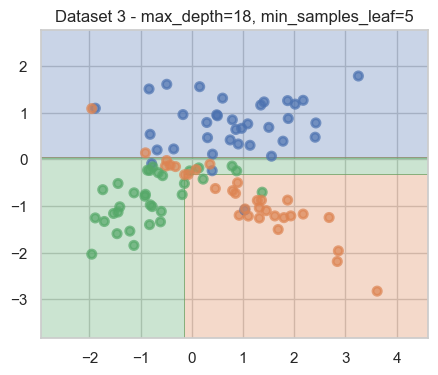

Dataset 3 - max_depth=18, min_samples_leaf=5 - Train Accuracy: 0.90, Test Accuracy: 0.77


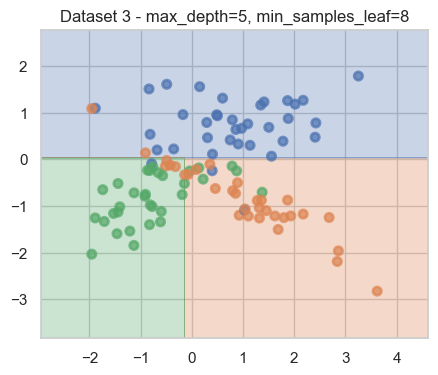

Dataset 3 - max_depth=5, min_samples_leaf=8 - Train Accuracy: 0.89, Test Accuracy: 0.77


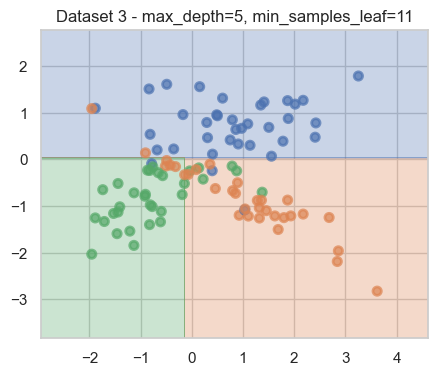

Dataset 3 - max_depth=5, min_samples_leaf=11 - Train Accuracy: 0.89, Test Accuracy: 0.77


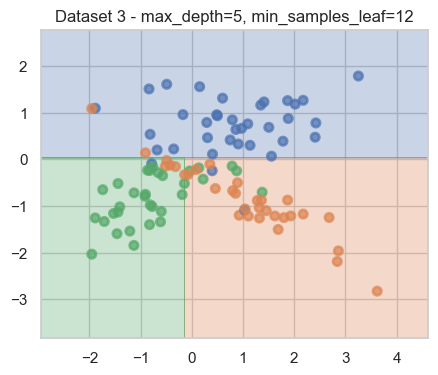

Dataset 3 - max_depth=5, min_samples_leaf=12 - Train Accuracy: 0.89, Test Accuracy: 0.77


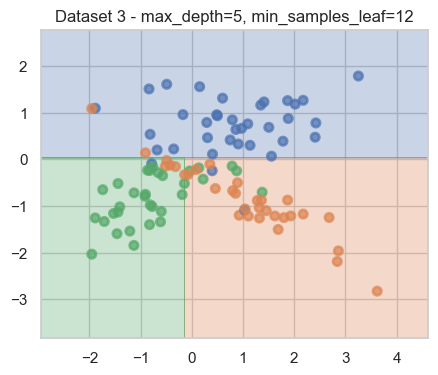

Dataset 3 - max_depth=5, min_samples_leaf=12 - Train Accuracy: 0.89, Test Accuracy: 0.77


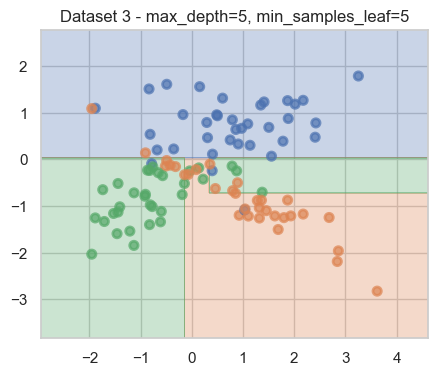

Dataset 3 - max_depth=5, min_samples_leaf=5 - Train Accuracy: 0.90, Test Accuracy: 0.70


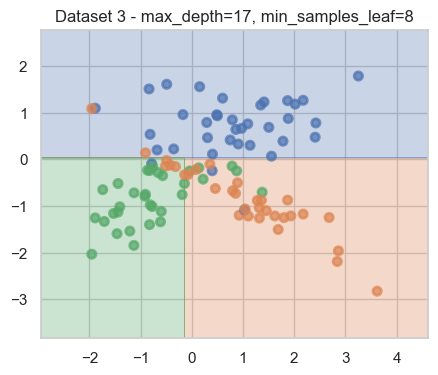

Dataset 3 - max_depth=17, min_samples_leaf=8 - Train Accuracy: 0.89, Test Accuracy: 0.77


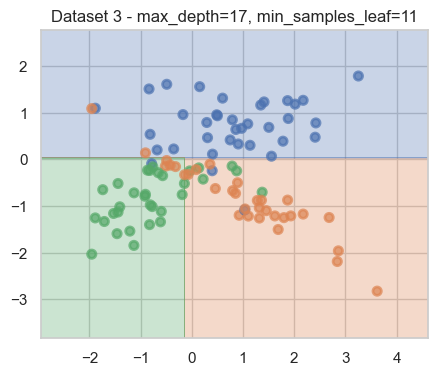

Dataset 3 - max_depth=17, min_samples_leaf=11 - Train Accuracy: 0.89, Test Accuracy: 0.77


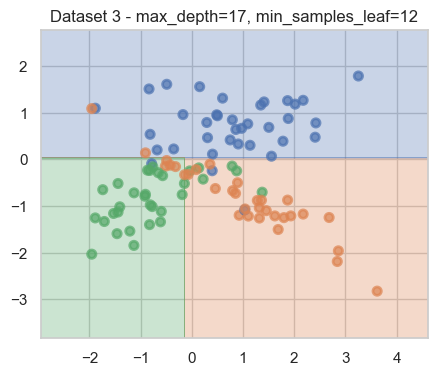

Dataset 3 - max_depth=17, min_samples_leaf=12 - Train Accuracy: 0.89, Test Accuracy: 0.77


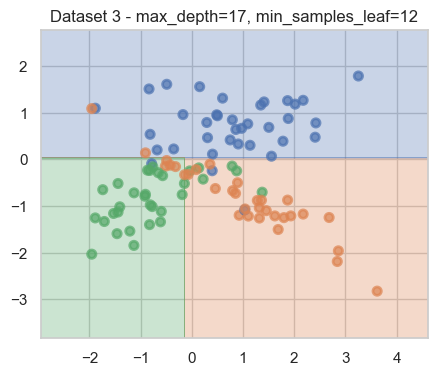

Dataset 3 - max_depth=17, min_samples_leaf=12 - Train Accuracy: 0.89, Test Accuracy: 0.77


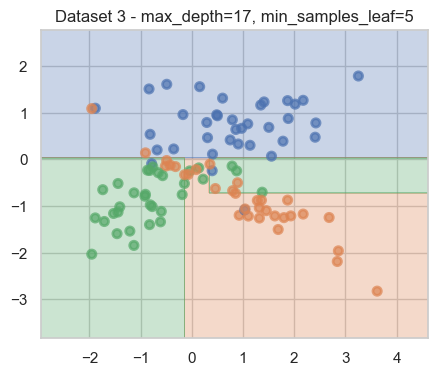

Dataset 3 - max_depth=17, min_samples_leaf=5 - Train Accuracy: 0.90, Test Accuracy: 0.70


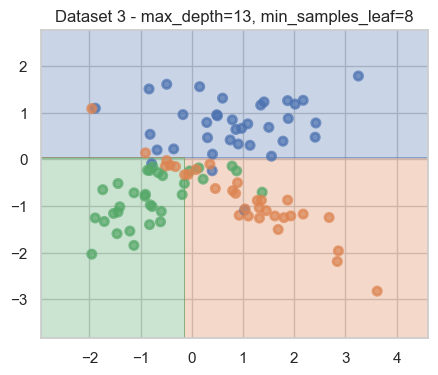

Dataset 3 - max_depth=13, min_samples_leaf=8 - Train Accuracy: 0.89, Test Accuracy: 0.77


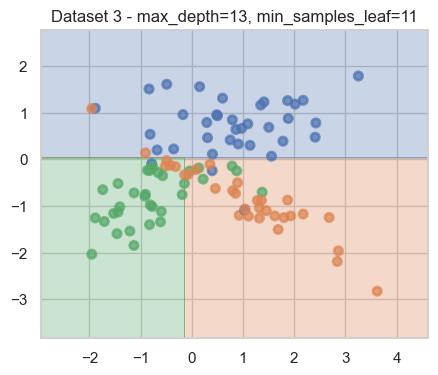

Dataset 3 - max_depth=13, min_samples_leaf=11 - Train Accuracy: 0.89, Test Accuracy: 0.77


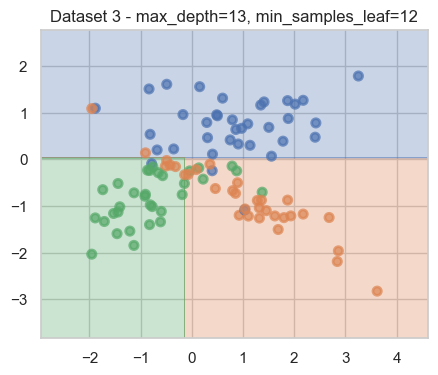

Dataset 3 - max_depth=13, min_samples_leaf=12 - Train Accuracy: 0.89, Test Accuracy: 0.77


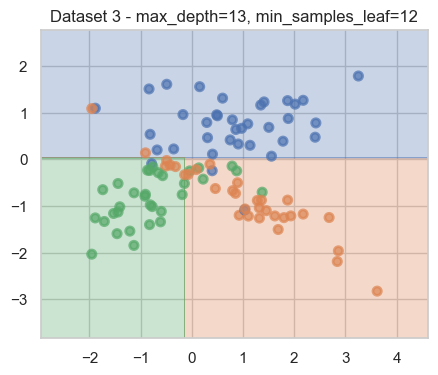

Dataset 3 - max_depth=13, min_samples_leaf=12 - Train Accuracy: 0.89, Test Accuracy: 0.77


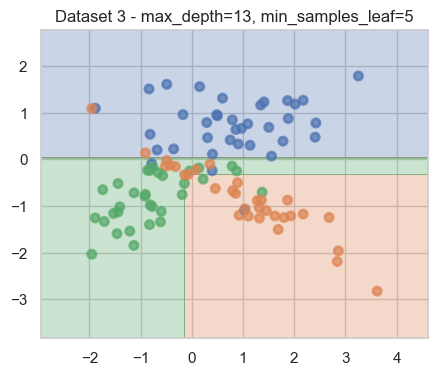

Dataset 3 - max_depth=13, min_samples_leaf=5 - Train Accuracy: 0.90, Test Accuracy: 0.77


In [8]:
max_depth_values = np.random.randint(1, 20, 5)
min_samples_leaf_values = np.random.randint(1, 20, 5)

for i, (X, y) in enumerate(datasets):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    for max_depth in max_depth_values:
        for min_samples_leaf in min_samples_leaf_values:
            clf = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf)
            clf.fit(X_train, y_train)
            
            plt.figure(figsize=(5, 4))
            plot_surface(clf, X, y)
            plt.title(f"Dataset {i+1} - max_depth={max_depth}, min_samples_leaf={min_samples_leaf}")
            plt.show()
            
            train_accuracy = clf.score(X_train, y_train)
            test_accuracy = clf.score(X_test, y_test)
            
            print(f"Dataset {i+1} - max_depth={max_depth}, min_samples_leaf={min_samples_leaf} - Train Accuracy: {train_accuracy:.2f}, Test Accuracy: {test_accuracy:.2f}")

__Ответ:__ в среднем видно, чем больше глубина и меньшнее кол-во семплов листьев, тем лучше показывает себя аккураси и тем лучше сами графики (под лучше я подразумеваю что нет подгона под данные). Наверное это оптимальный вариант, ведь чем больше глубина тем больше риск переобучиться, а чем меньше кол-во инфы (листьев) тем больше шанс потерять важную инфу, но такой вариант (глубина >> листья) возможно (как минимум тут) дает оптимальный вариант для обучения

# 2. Решающие деревья своими руками

В этой части вам нужно реализовать свой класс для обучения решающего дерева в задаче бинарной классификации с возможностью обработки вещественных и категориальных признаков.

__Задание 3. (1.5 балл)__

Реализуйте функцию find_best_split из модуля hw5code.py 

ПОСЫЛКА https://contest.yandex.ru/contest/72492/run-report/129666258/

__Задание 4. (0.5 балла)__

Загрузите таблицу [students.csv](https://github.com/esokolov/ml-course-hse/blob/master/2022-fall/homeworks-practice/homework-practice-05-trees/students.csv) (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте scatter-графики "значение признака — класс" для всех пяти признаков.

In [9]:
from hw5code import find_best_split

data = pd.read_csv('students.csv')

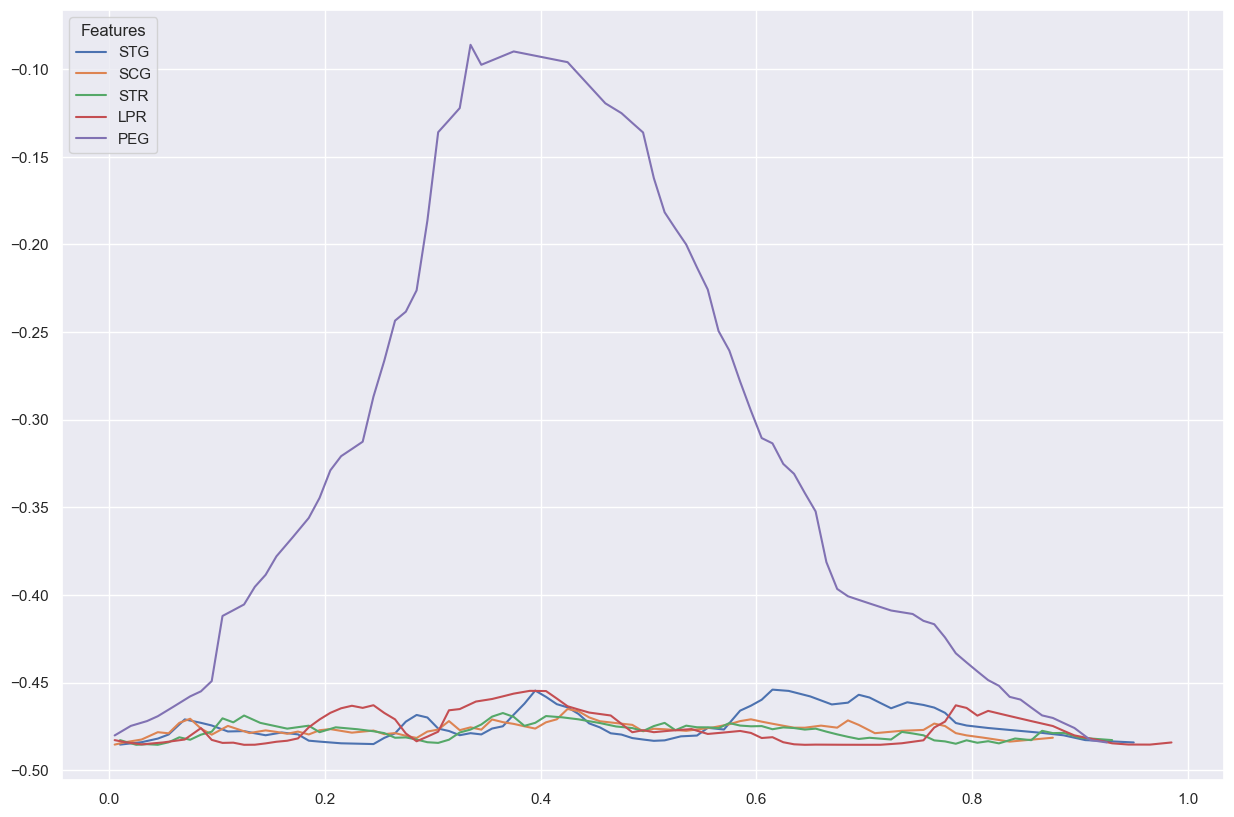

In [10]:
sns.set(rc={"figure.figsize": (15, 10)})
for col in data.columns[:-1]:
    thresholds, ginis, _, _ = find_best_split(np.array(data[col]), np.array(data['UNS']))
    sns.lineplot(x=thresholds, y=ginis, label=col)
plt.legend(title='Features', loc='upper left')
plt.show()

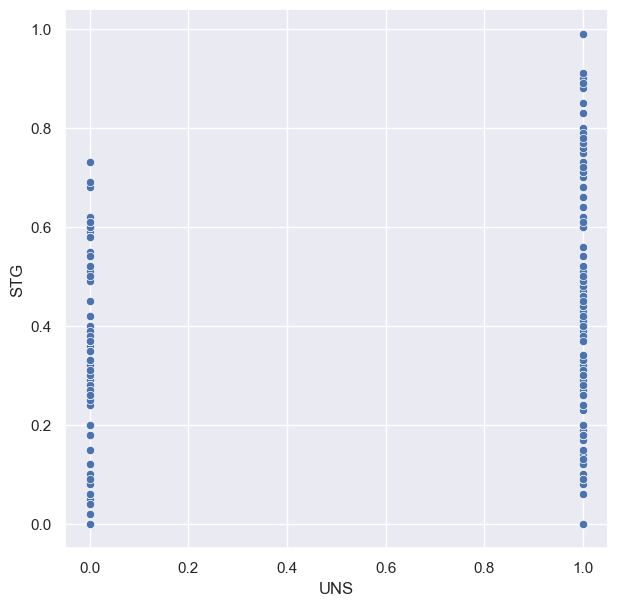

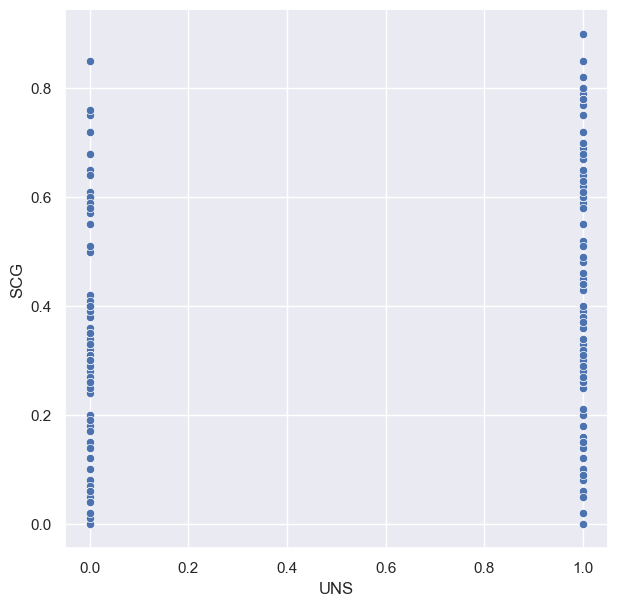

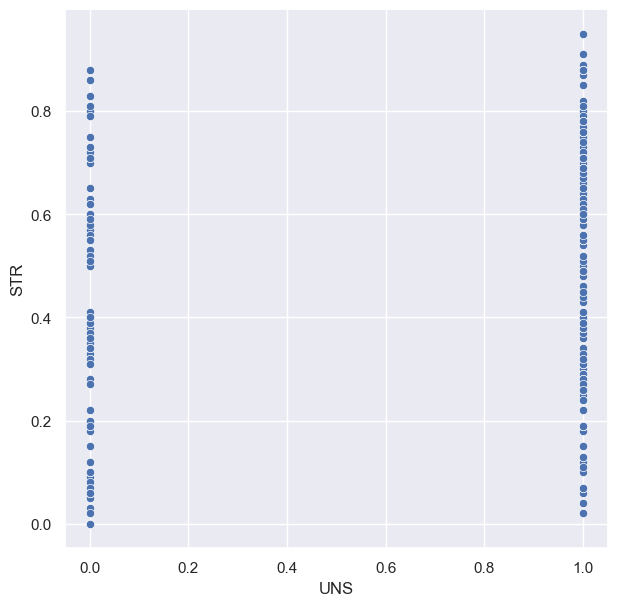

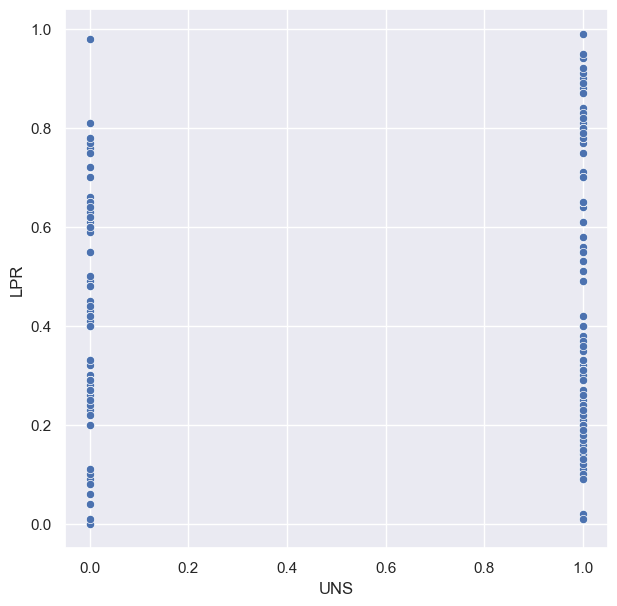

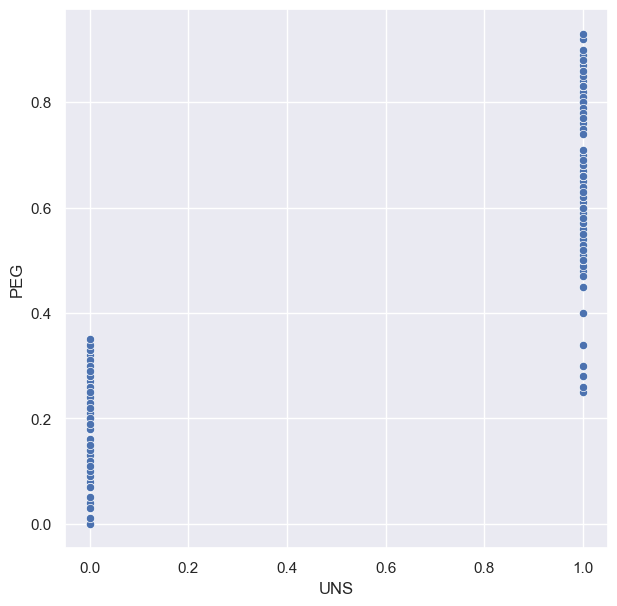

In [11]:
sns.set(rc={"figure.figsize":(7, 7)})
for col in data.columns[:-1]:
    sns.scatterplot(x=data['UNS'], y=data[col])
    plt.show()

__Задание 5. (0.5 балла)__

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой scatter-графиков? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

**Ответ:** По пегу (лучшая кривая значения джини). Скаттер это подверждает, видно что есть какой то порог который их начинает разделять четенько на два класса. Вид - ярковыраеная вершина. Они значительно хуже, многие колеблятся у +- тех же значений и не дают того пика, который дает пег (соотвественно деление хуже тк информативность хуже).

__Задание 6. (1.5 балла).__

Разберитесь с уже написанным кодом в классе DecisionTree модуля hw5code.py. Найдите ошибки в реализации метода \_fit_node. Напишите функцию \_predict_node.

 Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в [лекции](https://github.com/esokolov/ml-course-hse/blob/master/2020-fall/lecture-notes/lecture07-trees.pdf) в разделе «Построение дерева». Выбор лучшего разбиения необходимо производить по критерию Джини. Критерий останова: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку. Ответ в листе: наиболее часто встречающийся класс в листе. Для категориальных признаков выполняется преобразование, описанное в лекции в разделе «Учет категориальных признаков».

__Задание 7. (0.5 балла)__

Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Вам нужно скачать таблицу agaricus-lepiota.data (лежит на гитхабе вместе с заданием), прочитать ее с помощью pandas, применить к каждому столбцу LabelEncoder (из sklearn), чтобы преобразовать строковые имена категорий в натуральные числа. Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

У вас должно получиться значение accuracy, равное единице (или очень близкое к единице), и не очень глубокое дерево.

In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [13]:
mushrooms = pd.read_csv('agaricus-lepiota.data')

label_encoders = []
for column in mushrooms.columns:
    le = LabelEncoder()
    mushrooms[column] = le.fit_transform(mushrooms[column])
    label_encoders.append(le)

X = mushrooms.iloc[:, 1:].values
y = mushrooms.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 1.00


__Задание 8. (1 балл)__

Реализуйте в классе DecisionTree поддержку параметров max_depth, min_samples_split и min_samples_leaf по аналогии с DecisionTreeClassifier. Постройте графики зависимости качества предсказания в зависимости от этих параметров для набора данных tic-tac-toe (https://github.com/esokolov/ml-course-hse/blob/master/2024-fall/homework-practice/homework-practice-05-trees/tic-tac-toe-endgame.csv).

ПОСЫЛКА -- https://contest.yandex.ru/contest/72492/run-report/129690991/

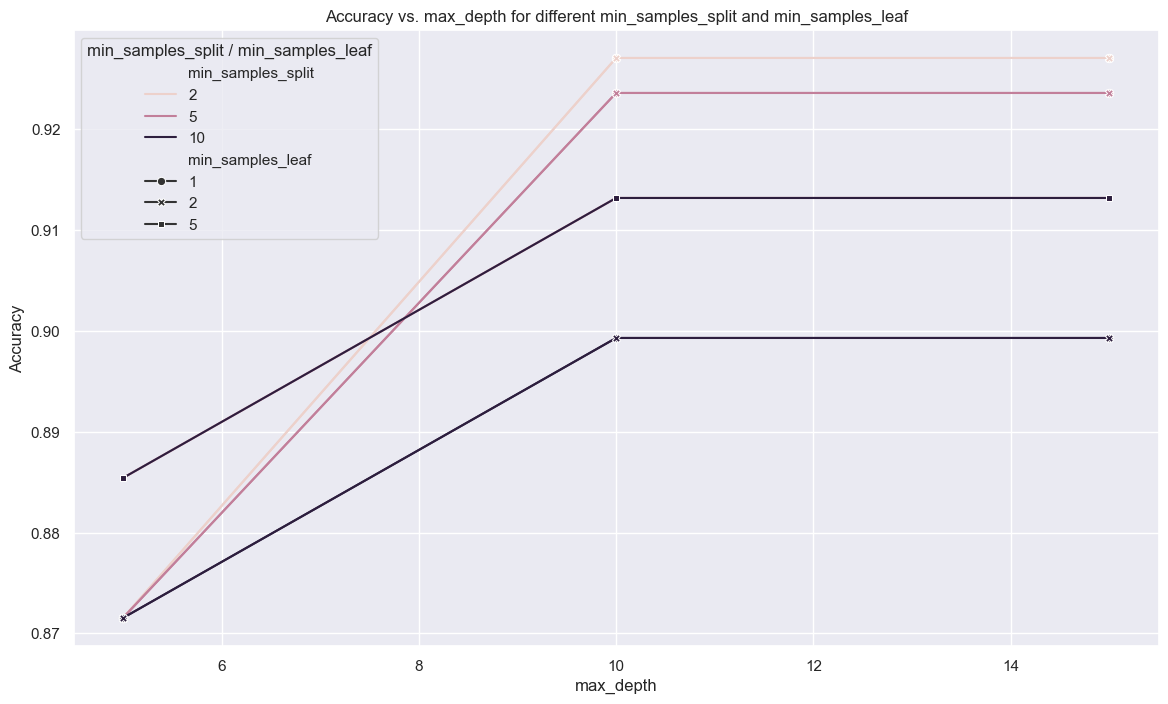

In [14]:
from hw5code import DecisionTree

data = pd.read_csv('tic-tac-toe-endgame.csv')

X = data.drop(columns=['V10'])
y = data['V10'].apply(lambda x: 1 if x == 'positive' else 0)

X = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

max_depths = [None, 5, 10, 15]
min_samples_splits = [2, 5, 10]
min_samples_leafs = [1, 2, 5]

results = []

for max_depth in max_depths:
    for min_samples_split in min_samples_splits:
        for min_samples_leaf in min_samples_leafs:
            feature_types = ['real'] * X_train.shape[1]
            tree = DecisionTree(
                feature_types=feature_types,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf
            )
            tree.fit(X_train.values, y_train.values)
            y_pred = tree.predict(X_test.values)
            accuracy = accuracy_score(y_test, y_pred)
            results.append({
                'max_depth': max_depth,
                'min_samples_split': min_samples_split,
                'min_samples_leaf': min_samples_leaf,
                'accuracy': accuracy
            })

results_df = pd.DataFrame(results)


plt.figure(figsize=(14, 8))
sns.lineplot(data=results_df, x='max_depth', y='accuracy', hue='min_samples_split', style='min_samples_leaf', markers=True, dashes=False)
plt.title('Accuracy vs. max_depth for different min_samples_split and min_samples_leaf')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend(title='min_samples_split / min_samples_leaf')
plt.show()

__Задание 9. (до 3-х баллов)__

Реализуйте класс `LinearRegressionTree`:

 - Если вам удобно, можете сделать его наследуемым от `DecisionTree` и переопределить только необходимые методы. Можете добавить новые — как вам нравится.
 - В листьях находятся не константные предсказания, а линейные модели (можно использовать из библиотеки `sklearn`).
 - Ваша реализация должна решать задачу __регрессии__, поэтому для поиска оптимального разбиения нужно написать новую функцию.
 - **Максимум 1.8 балла, если**:
   - В качестве критерия для разбиения считаете среднее квадратное/абсолютное отклонение
   - Перебираете все пороги
   - Ваша реализация строится как обычное решающее дерево для регрессии, но в листьях линейные модели.
   - Есть поддержка параметра max_depth
 - **Максимум три балла, если выполнено следующее**:
     - Для разбиения перебираются не все пороги. Пороги выбираются из значений признаков, разбитых на квантили.
     - Для разбиении выбирается порог, который минимизирует суммарную ошибку линейных моделей после разбиения: $$\text{loss} = \frac{n_{left}}{n} \cdot \text{loss}_{left} + \frac{n_{right}}{n} \cdot \text{loss}_{right}$$ (Разумеется, для оценки этих ошибок вам надо будет строить много линейных моделей, это не дисперсии. В качестве функционала ошибки возьмите MAE или MSE)
     - Есть поддержка параметров max_depth, min_samples_split, min_samples_leaf

сделал

__Задание 10. (1 балл)__

Проведите эксперименты с реализованным вами линейным деревом на любом подходящем датасете из sklearn (https://scikit-learn.org/1.5/datasets/real_world.html), который вам нравится. Подберите лучшие гиперпараметры (max_depth и остальные, если вы их реализовывали). Сравните ваше дерево со стандартным деревом для регрессии из sklearn, для него тоже подберите гиперпараметры.

In [18]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from hw5code import LinearRegressionTree

data = fetch_california_housing()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

max_depths = [5, 10]  
min_samples_splits = [2, 5]  
min_samples_leafs = [1, 2]  

def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)
    return train_mse, test_mse

linear_tree_results = []
for max_depth in max_depths:
    for min_samples_split in min_samples_splits:
        for min_samples_leaf in min_samples_leafs:
            linear_tree = LinearRegressionTree(
                feature_types=["real"] * X_train.shape[1],
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                n_quantiles=5
            )
            train_mse, test_mse = evaluate_model(linear_tree, X_train, y_train, X_test, y_test)
            linear_tree_results.append({
                'model': 'LinearRegressionTree',
                'max_depth': max_depth,
                'min_samples_split': min_samples_split,
                'min_samples_leaf': min_samples_leaf,
                'train_mse': train_mse,
                'test_mse': test_mse
            })

decision_tree_results = []
for max_depth in max_depths:
    for min_samples_split in min_samples_splits:
        for min_samples_leaf in min_samples_leafs:
            decision_tree = DecisionTreeRegressor(
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf
            )
            train_mse, test_mse = evaluate_model(decision_tree, X_train, y_train, X_test, y_test)
            decision_tree_results.append({
                'model': 'DecisionTreeRegressor',
                'max_depth': max_depth,
                'min_samples_split': min_samples_split,
                'min_samples_leaf': min_samples_leaf,
                'train_mse': train_mse,
                'test_mse': test_mse
            })

results = linear_tree_results + decision_tree_results
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by=['model', 'max_depth', 'min_samples_split', 'min_samples_leaf'])

print("Результаты сравнения моделей:")
print(results_df)  

print("\nЛучший результат для LinearRegressionTree:")
best_lrt = results_df[results_df['model'] == 'LinearRegressionTree'].sort_values('test_mse').iloc[0]
print(best_lrt)

print("\nЛучший результат для DecisionTreeRegressor:")
best_dtr = results_df[results_df['model'] == 'DecisionTreeRegressor'].sort_values('test_mse').iloc[0]
print(best_dtr)


Результаты сравнения моделей:
                    model  max_depth  min_samples_split  min_samples_leaf  \
8   DecisionTreeRegressor          5                  2                 1   
9   DecisionTreeRegressor          5                  2                 2   
10  DecisionTreeRegressor          5                  5                 1   
11  DecisionTreeRegressor          5                  5                 2   
12  DecisionTreeRegressor         10                  2                 1   
13  DecisionTreeRegressor         10                  2                 2   
14  DecisionTreeRegressor         10                  5                 1   
15  DecisionTreeRegressor         10                  5                 2   
0    LinearRegressionTree          5                  2                 1   
1    LinearRegressionTree          5                  2                 2   
2    LinearRegressionTree          5                  5                 1   
3    LinearRegressionTree          5          

Посмотрите, что будет, если обучить ваше дерево на данных, которые сгенерированы внизу. Нарисуйте график с предсказаниями и таргетами на всей выборке, сравните с обычным деревом.

Напишите, какие достоинства и недостатки вы видите у реализованного вами линейного дерева.

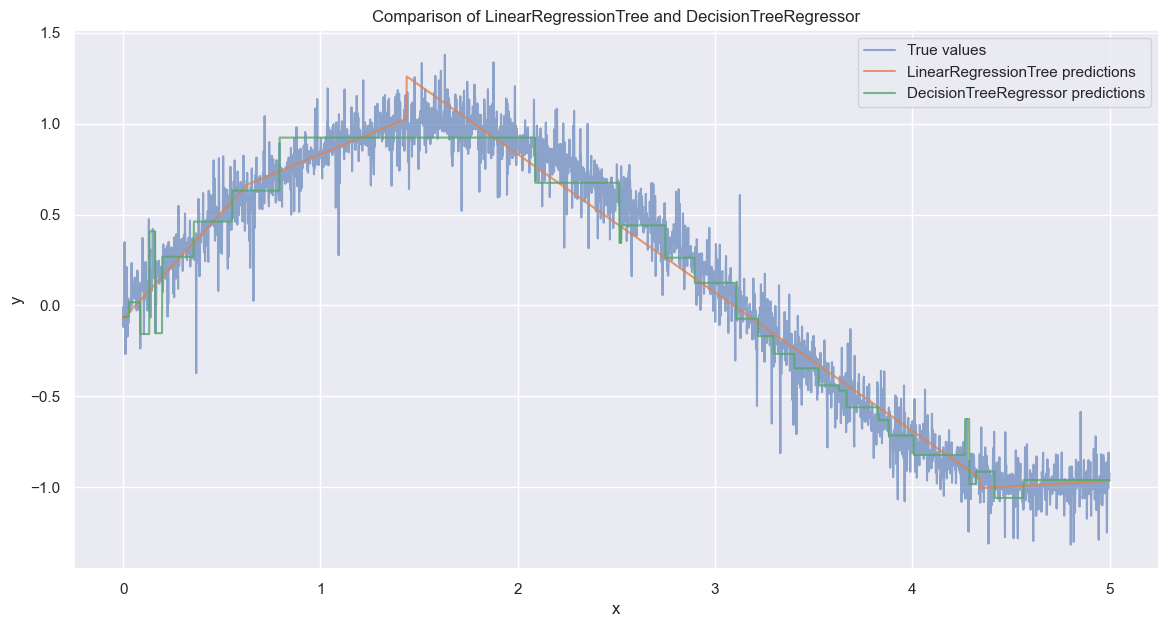

In [23]:
n_samples = 3_000
x = np.linspace(0, 5, n_samples).reshape(-1, 1)
y = np.sin(x.flatten()) + np.random.normal(0, 0.1, n_samples) * np.random.normal(0, 1, n_samples)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.95, random_state=0x4b524f4c2d562d53544f594c4f % (2 ** 32 - 1))

linear_tree = LinearRegressionTree(feature_types=["real"], max_depth=2)
linear_tree.fit(x_train, y_train)
y_pred_linear_tree = linear_tree.predict(x)

decision_tree = DecisionTreeRegressor(max_depth=5, min_samples_split=2, min_samples_leaf=1)
decision_tree.fit(x_train, y_train)
y_pred_decision_tree = decision_tree.predict(x)

plt.figure(figsize=(14, 7))
plt.plot(x, y, label='True values', alpha=0.6)
plt.plot(x, y_pred_linear_tree, label='LinearRegressionTree predictions', alpha=0.8)
plt.plot(x, y_pred_decision_tree, label='DecisionTreeRegressor predictions', alpha=0.8)
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparison of LinearRegressionTree and DecisionTreeRegressor')
plt.show()

# YOUR CODE

In [24]:
mse_decision_tree = mean_squared_error(y, y_pred_decision_tree)
print(f'MSE for DecisionTreeRegressor: {mse_decision_tree:.4f}')

mse_linear_tree = mean_squared_error(y, y_pred_linear_tree)
print(f'MSE for LinearRegressionTree: {mse_linear_tree:.4f}')

MSE for DecisionTreeRegressor: 0.0162
MSE for LinearRegressionTree: 0.0155


**Ответ:** Ужасно подбирать гиперпараметры. При попытке сделать обучение хоть чуть чуть с разнообразными гиперпараметрами, приводило модель к адовому обучению на час+ и мне приходилось стопать. Поэтому минус - долго обучать и сложный подбор параметров. Из плюсов можно заметить что мсе чуть чуть, но лучше склерновского, поэтому плюс реализации в том что даже при таких скромных настройках качество не 1 (типо не произошел подгон под данные, хотя вполне мог).

Вставьте что угодно, описывающее ваши впечатления от этого задания: